In [17]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
print("Installing dependencies...")
!pip install torch torchvision pillow matplotlib -q
print("Installation complete!")

Installing dependencies...
Installation complete!


In [19]:
import os
import numpy as np
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
import random
from pathlib import Path
print("All imports successful!")

All imports successful!


Configuration

In [20]:
IMAGE_CONFIG = {
    'img_size': 256,
    'train_split': 0.7,
    'val_split': 0.15,
    'test_split': 0.15,
    'seed': 42,
    'attack_augmentations': {
        'jpeg_quality': [30, 50, 70],
        'gaussian_noise_std': 0.02,
        'resize_factor': 0.8
    }
}
print(f"Config: {IMAGE_CONFIG['img_size']}x{IMAGE_CONFIG['img_size']} images")

Config: 256x256 images


FLEXIBLE Image Loading Function

In [21]:
def load_cat_dog_images(root_dir):
    """
    FLEXIBLE loader - handles multiple folder structures:
    1. /root_dir/cats_set/ and /root_dir/dogs_set/
    2. /root_dir/Cat/ and /root_dir/Dog/
    3. /root_dir/ with files named cat.*.jpg and dog.*.jpg
    """
    image_paths = []

    if not os.path.exists(root_dir):
        print(f"ERROR: {root_dir} does not exist!")
        print("\nPlease check:")
        print("1. Is the folder name spelled correctly?")
        print("2. Did you upload the dataset to Google Drive?")
        print("3. Is Google Drive mounted?")
        return image_paths

    print(f"✓ Found root directory: {root_dir}")

    # Try multiple possible folder name patterns
    cat_names = ['cats_set', 'Cat', 'Cats', 'cats', 'cat']
    dog_names = ['dogs_set', 'Dog', 'Dogs', 'dogs', 'dog']

    # STRATEGY 1: Look for cat/dog subfolders
    cats_dir = None
    for name in cat_names:
        test_path = os.path.join(root_dir, name)
        if os.path.exists(test_path) and os.path.isdir(test_path):
            cats_dir = test_path
            print(f"✓ Found cat folder: {name}/")
            break

    dogs_dir = None
    for name in dog_names:
        test_path = os.path.join(root_dir, name)
        if os.path.exists(test_path) and os.path.isdir(test_path):
            dogs_dir = test_path
            print(f"✓ Found dog folder: {name}/")
            break

    # Load from subfolders if found
    if cats_dir:
        cat_files = [f for f in os.listdir(cats_dir)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_name in cat_files:
            image_paths.append((os.path.join(cats_dir, img_name), 0, 'cat'))
        print(f"   → Loaded {len(cat_files)} cat images")

    if dogs_dir:
        dog_files = [f for f in os.listdir(dogs_dir)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_name in dog_files:
            image_paths.append((os.path.join(dogs_dir, img_name), 1, 'dog'))
        print(f"   → Loaded {len(dog_files)} dog images")

    # STRATEGY 2: If no subfolders found, look for files in root
    if not cats_dir and not dogs_dir:
        print("No cat/dog subfolders found. Searching root directory...")
        all_files = [f for f in os.listdir(root_dir)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for filename in all_files:
            filepath = os.path.join(root_dir, filename)
            filename_lower = filename.lower()

            if 'cat' in filename_lower:
                image_paths.append((filepath, 0, 'cat'))
            elif 'dog' in filename_lower:
                image_paths.append((filepath, 1, 'dog'))

        cats = sum(1 for _, label, _ in image_paths if label == 0)
        dogs = sum(1 for _, label, _ in image_paths if label == 1)
        print(f"   → Found {cats} cat images")
        print(f"   → Found {dogs} dog images")

    print(f"\n✓ Total images loaded: {len(image_paths)}")

    if len(image_paths) == 0:
        print("\nNO IMAGES FOUND!")
        print("\n🔍 Debug info:")
        print(f"   Root directory exists: {os.path.exists(root_dir)}")
        if os.path.exists(root_dir):
            contents = os.listdir(root_dir)
            print(f"   Contents ({len(contents)} items):")
            for item in contents[:20]:  # Show first 20
                print(f"      • {item}")

    return image_paths

def split_dataset(image_paths, config):
    """Split into train/val/test"""
    random.seed(config['seed'])
    np.random.seed(config['seed'])

    random.shuffle(image_paths)

    n = len(image_paths)
    train_end = int(n * config['train_split'])
    val_end = train_end + int(n * config['val_split'])

    splits = {
        'train': image_paths[:train_end],
        'val': image_paths[train_end:val_end],
        'test': image_paths[val_end:]
    }

    print(f"\nDataset split:")
    print(f"   Train: {len(splits['train'])} images ({config['train_split']*100:.0f}%)")
    print(f"   Val:   {len(splits['val'])} images ({config['val_split']*100:.0f}%)")
    print(f"   Test:  {len(splits['test'])} images ({config['test_split']*100:.0f}%)")

    return splits

print("✓ Loading functions ready!")

✓ Loading functions ready!


Transform Functions

In [22]:
def create_base_transform(img_size):
    """Basic preprocessing transform"""
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

def create_jpeg_compression(quality):
    """Simulate JPEG compression attack"""
    def compress(img_tensor):
        img = transforms.ToPILImage()(img_tensor)
        from io import BytesIO
        buffer = BytesIO()
        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        compressed = Image.open(buffer).convert('RGB')
        return transforms.ToTensor()(compressed)
    return compress

def create_gaussian_noise(std):
    """Add Gaussian noise attack"""
    def add_noise(img_tensor):
        noise = torch.randn_like(img_tensor) * std
        return torch.clamp(img_tensor + noise, 0, 1)
    return add_noise

def create_resize_crop(resize_factor, img_size):
    """Resize and crop attack"""
    new_size = int(img_size * resize_factor)
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((new_size, new_size)),
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

def create_attack_transforms(config):
    """Create all attack augmentation transforms"""
    img_size = config['img_size']
    attack_config = config['attack_augmentations']

    transforms_dict = {
        'jpeg_30': create_jpeg_compression(30),
        'jpeg_50': create_jpeg_compression(50),
        'jpeg_70': create_jpeg_compression(70),
        'gaussian_noise': create_gaussian_noise(attack_config['gaussian_noise_std']),
        'resize_crop': create_resize_crop(attack_config['resize_factor'], img_size),
        'none': lambda x: x
    }
    print(f"Created {len(transforms_dict)} attack transforms")
    return transforms_dict

print("Transform functions ready!")

Transform functions ready!


Processing Functions

In [23]:
def process_image(img_path, transform, save_as_numpy=True):
    """Process a single image"""
    try:
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img)

        if save_as_numpy:
            img_array = img_tensor.permute(1, 2, 0).numpy()
            return img_array
        else:
            return img_tensor

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

def process_split(split_data, transform, split_name, output_dir):
    """Process entire split and save"""
    print(f"\nProcessing {split_name} split...")

    images = []
    labels = []
    paths = []

    for i, (img_path, label, category) in enumerate(split_data):
        img_array = process_image(img_path, transform)

        if img_array is not None:
            images.append(img_array)
            labels.append(label)
            paths.append(img_path)

        if (i + 1) % 100 == 0:
            print(f"   Processed {i+1}/{len(split_data)}")

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)

    np.save(f"{output_dir}/{split_name}_images.npy", images)
    np.save(f"{output_dir}/{split_name}_labels.npy", labels)

    with open(f"{output_dir}/{split_name}_paths.txt", "w") as f:
        for path in paths:
            f.write(path + "\n")

    print(f"Saved {len(images)} images")
    print(f"Shape: {images.shape}")

    return images, labels

print("Processing functions ready!")

Processing functions ready!


Visualization Functions

In [24]:
def visualize_samples(images, labels, num_samples=9):
    """Visualize sample images from dataset"""
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    indices = np.random.choice(len(images), min(num_samples, len(images)), replace=False)

    for idx, ax in zip(indices, axes):
        img = images[idx]
        label = labels[idx]

        ax.imshow(img)
        ax.set_title(f"{'Cat' if label == 0 else 'Dog'}", fontsize=14)
        ax.axis('off')

    plt.tight_layout()
    return fig

def visualize_attacks(img_tensor, attack_transforms):
    """Visualize different attack augmentations"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    axes[0].imshow(img_tensor.permute(1, 2, 0))
    axes[0].set_title("Original", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    attack_names = ['jpeg_30', 'jpeg_50', 'jpeg_70', 'gaussian_noise', 'resize_crop']
    for i, attack_name in enumerate(attack_names):
        attacked = attack_transforms[attack_name](img_tensor)
        axes[i+1].imshow(attacked.permute(1, 2, 0))
        axes[i+1].set_title(attack_name.replace('_', ' ').title(), fontsize=12)
        axes[i+1].axis('off')

    plt.tight_layout()
    return fig

def compute_statistics(images, split_name):
    """Compute dataset statistics"""
    print(f"\nStatistics for {split_name}:")
    print(f"   Shape: {images.shape}")
    print(f"   Dtype: {images.dtype}")
    print(f"   Min value: {images.min():.4f}")
    print(f"   Max value: {images.max():.4f}")
    print(f"   Mean: {images.mean():.4f}")
    print(f"   Std: {images.std():.4f}")

    for c, color in enumerate(['Red', 'Green', 'Blue']):
        channel_data = images[:, :, :, c]
        print(f"   {color} channel - Mean: {channel_data.mean():.4f}, Std: {channel_data.std():.4f}")

print("Visualization functions ready!")

Visualization functions ready!


Main Pipeline

In [25]:
def main(dataset_root, output_dir):
    """Complete image preprocessing pipeline"""

    print("="*70)
    print("IMAGE PREPROCESSING FOR STEGANOGRAPHY")
    print("="*70)

    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "="*70)
    print("📂 STEP 1: LOADING IMAGES")
    print("="*70)
    image_paths = load_cat_dog_images(dataset_root)

    if len(image_paths) == 0:
        print("\nFAILED: No images found!")
        print("\nACTION REQUIRED:")
        print("   1. Upload your cat and dog images to Google Drive")
        print("   2. Organize them in one of these structures:")
        print("      Option A: /dataset_root/cats_set/ and /dataset_root/dogs_set/")
        print("      Option B: /dataset_root/Cat/ and /dataset_root/Dog/")
        print("      Option C: /dataset_root/ with files like 'cat.1.jpg', 'dog.1.jpg'")
        print("   3. Update the dataset_root path in CELL 11")
        return None

    print("\n" + "="*70)
    print("✂️  STEP 2: SPLITTING DATASET")
    print("="*70)
    splits = split_dataset(image_paths, IMAGE_CONFIG)

    print("\n" + "="*70)
    print("🔧 STEP 3: CREATING TRANSFORMS")
    print("="*70)
    base_transform = create_base_transform(IMAGE_CONFIG['img_size'])
    attack_transforms = create_attack_transforms(IMAGE_CONFIG)

    print("\n" + "="*70)
    print("STEP 4: PROCESSING SPLITS")
    print("="*70)

    train_images, train_labels = process_split(
        splits['train'], base_transform, 'train', output_dir
    )

    val_images, val_labels = process_split(
        splits['val'], base_transform, 'val', output_dir
    )

    test_images, test_labels = process_split(
        splits['test'], base_transform, 'test', output_dir
    )

    print("\n" + "="*70)
    print("STEP 5: SAVING METADATA")
    print("="*70)

    metadata = {
        'config': IMAGE_CONFIG,
        'total_images': len(image_paths),
        'splits': {
            'train': len(train_images),
            'val': len(val_images),
            'test': len(test_images)
        },
        'class_mapping': {0: 'cat', 1: 'dog'},
        'image_shape': list(train_images.shape[1:]),
        'attack_transforms': list(attack_transforms.keys())
    }

    with open(f"{output_dir}/image_preprocessing_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("✓ Metadata saved")

    print("\n" + "="*70)
    print("STEP 6: COMPUTING STATISTICS")
    print("="*70)

    compute_statistics(train_images, "Train")
    compute_statistics(val_images, "Val")
    compute_statistics(test_images, "Test")

    print("\n" + "="*70)
    print("👀 STEP 7: VISUALIZING SAMPLES")
    print("="*70)

    fig_samples = visualize_samples(train_images, train_labels)
    fig_samples.savefig(f"{output_dir}/sample_images.png", dpi=150, bbox_inches='tight')
    print("✓ Sample visualization saved")

    sample_img = torch.tensor(train_images[0]).permute(2, 0, 1)
    fig_attacks = visualize_attacks(sample_img, attack_transforms)
    fig_attacks.savefig(f"{output_dir}/attack_augmentations.png", dpi=150, bbox_inches='tight')
    print("✓ Attack visualization saved")

    print("\n" + "="*70)
    print("PREPROCESSING COMPLETE!")
    print("="*70)
    print(f"\nOutput directory: {output_dir}")
    print(f"\nFinal Statistics:")
    print(f"   Total images: {metadata['total_images']}")
    print(f"   Train: {metadata['splits']['train']}")
    print(f"   Val: {metadata['splits']['val']}")
    print(f"   Test: {metadata['splits']['test']}")

    return metadata

🔍 STEP 0: LOCATING YOUR DATASET
✓ FOUND: /content/drive/MyDrive/threec/cat and dogs image dataset

Using dataset: /content/drive/MyDrive/threec/cat and dogs image dataset

Starting preprocessing...

IMAGE PREPROCESSING FOR STEGANOGRAPHY

📂 STEP 1: LOADING IMAGES
✓ Found root directory: /content/drive/MyDrive/threec/cat and dogs image dataset
✓ Found cat folder: cats_set/
✓ Found dog folder: dogs_set/
   → Loaded 500 cat images
   → Loaded 500 dog images

✓ Total images loaded: 1000

✂️  STEP 2: SPLITTING DATASET

Dataset split:
   Train: 700 images (70%)
   Val:   150 images (15%)
   Test:  150 images (15%)

🔧 STEP 3: CREATING TRANSFORMS
Created 6 attack transforms

STEP 4: PROCESSING SPLITS

Processing train split...
   Processed 100/700
   Processed 200/700
   Processed 300/700
   Processed 400/700
   Processed 500/700
   Processed 600/700
   Processed 700/700
Saved 700 images
Shape: (700, 256, 256, 3)

Processing val split...
   Processed 100/150
Saved 150 images
Shape: (150, 256, 2

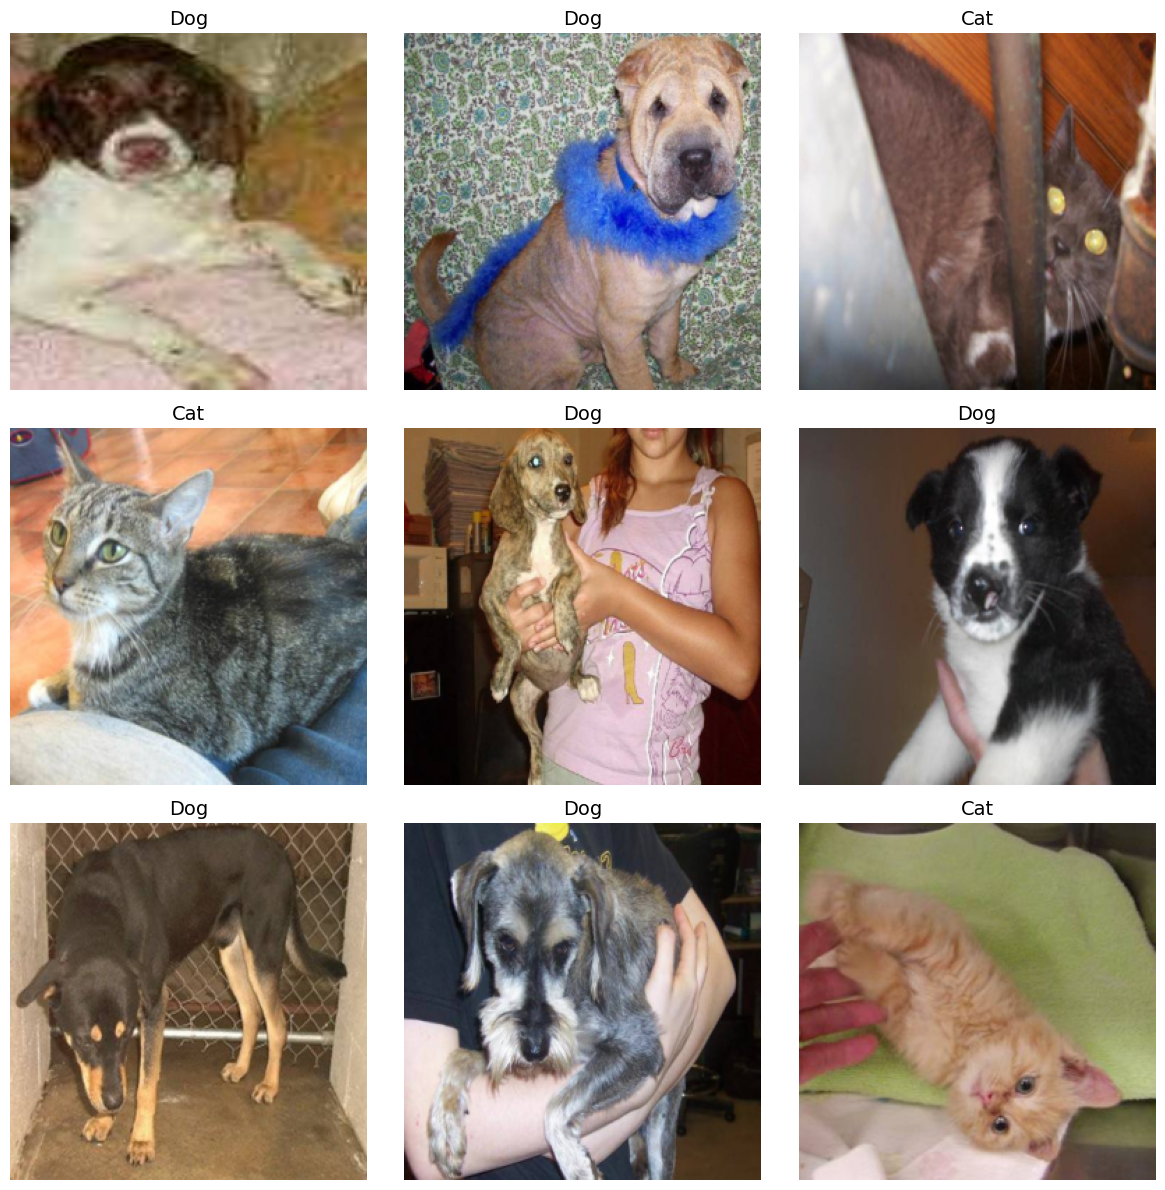

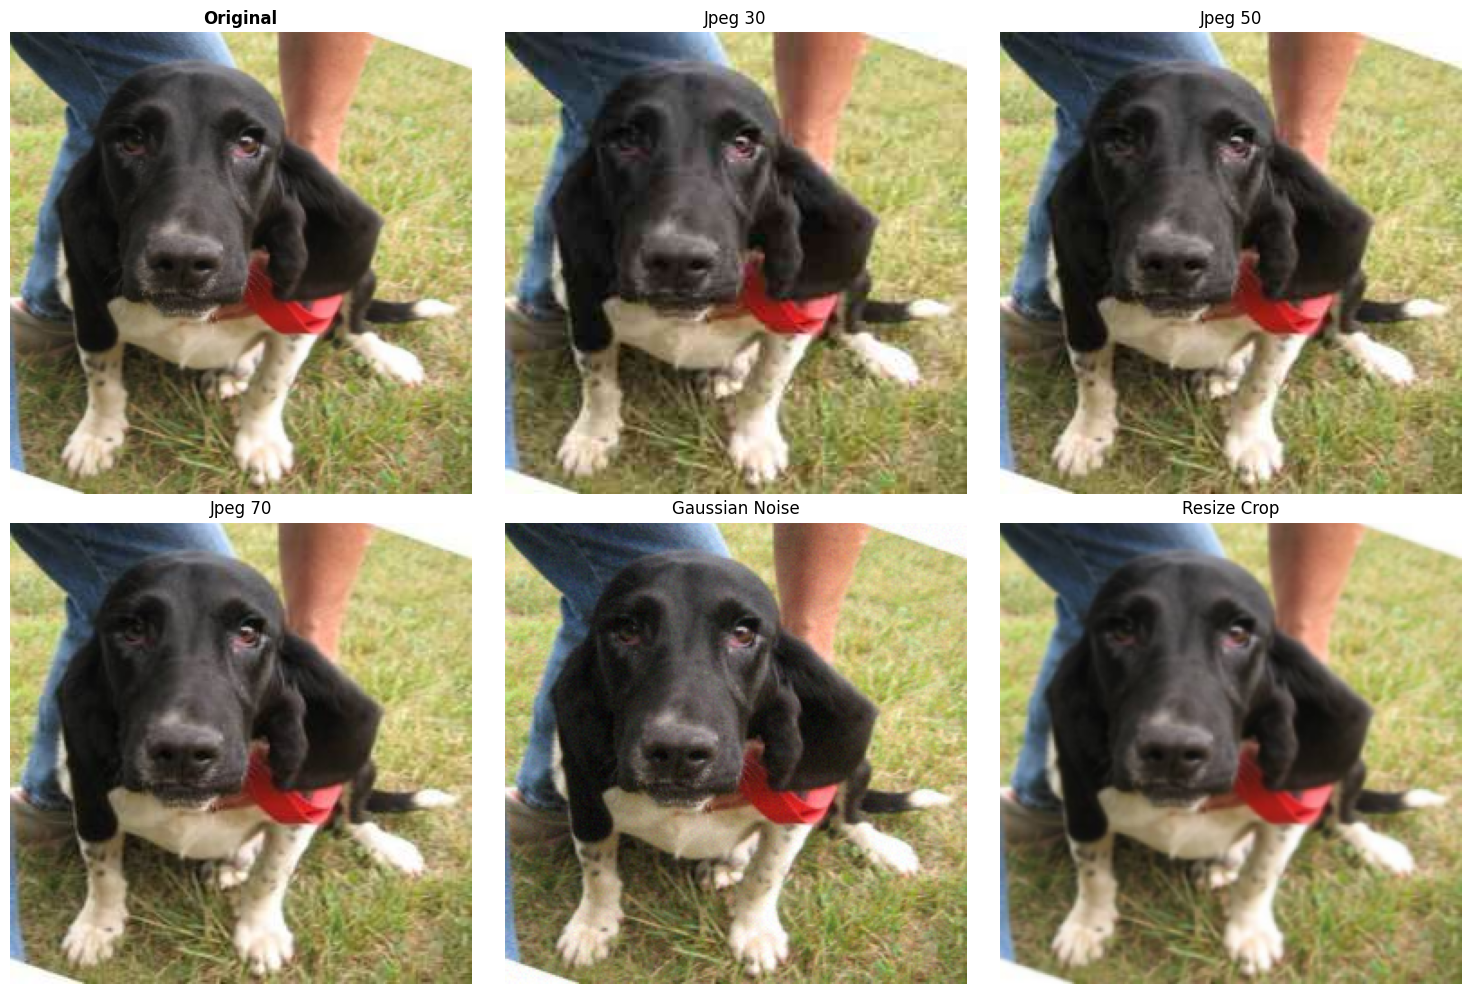

In [26]:
print("="*70)
print("🔍 STEP 0: LOCATING YOUR DATASET")
print("="*70)
search_locations = [
    "/content/drive/MyDrive/threec/cat and dogs image dataset",
    "/content/drive/MyDrive/cat and dogs image dataset",
    "/content/drive/MyDrive/Colab Notebooks/cat and dogs image dataset",
    "/content/drive/My Drive/threec/cat and dogs image dataset",
]
dataset_root = None
for path in search_locations:
    if os.path.exists(path):
        print(f"✓ FOUND: {path}")
        dataset_root = path
        break
    else:
        print(f"✗ Not here: {path}")

if dataset_root is None:
    print("\nDataset not found in common locations!")
    print("\nPlease manually set your dataset path:")
    print("   dataset_root = '/content/drive/MyDrive/YOUR/PATH/HERE'")
    print("\nOr upload your images to one of these locations:")
    for loc in search_locations[:2]:
        print(f"   • {loc}")
else:
    print(f"\nUsing dataset: {dataset_root}")
    output_dir = "/content/drive/MyDrive/threec/processed_images"

    print("\nStarting preprocessing...\n")
    metadata = main(dataset_root, output_dir)

    if metadata:
        print(f"\nSUCCESS!")
        print(f"Processed images saved to: {output_dir}")

Helper function for training

In [27]:
def load_preprocessed_images(output_dir):
    """Quick function to load preprocessed images for training"""
    print("Loading preprocessed images...")

    train_images = np.load(f"{output_dir}/train_images.npy")
    train_labels = np.load(f"{output_dir}/train_labels.npy")
    val_images = np.load(f"{output_dir}/val_images.npy")
    val_labels = np.load(f"{output_dir}/val_labels.npy")
    test_images = np.load(f"{output_dir}/test_images.npy")
    test_labels = np.load(f"{output_dir}/test_labels.npy")

    with open(f"{output_dir}/image_preprocessing_metadata.json", "r") as f:
        metadata = json.load(f)

    print(f"Loaded {len(train_images)} train, {len(val_images)} val, {len(test_images)} test images")

    return {
        'train': (train_images, train_labels),
        'val': (val_images, val_labels),
        'test': (test_images, test_labels),
        'metadata': metadata
    }

print("\nHelper function ready: load_preprocessed_images(output_dir)")


Helper function ready: load_preprocessed_images(output_dir)


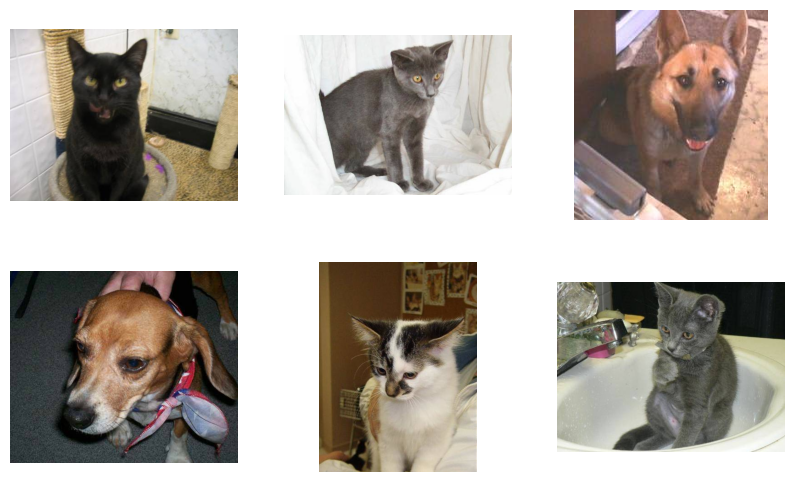

In [28]:
import glob, random
from PIL import Image
import matplotlib.pyplot as plt

base = "/content/drive/MyDrive/threec/cat and dogs image dataset"
paths = glob.glob(f"{base}/cats_set/*.*") + glob.glob(f"{base}/dogs_set/*.*")

n = min(6, len(paths))
samples = random.sample(paths, n)

plt.figure(figsize=(10,6))
for i, img_path in enumerate(samples):
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()
